# Adaptive Transfer Learning for Daily Physical Activity Monitoring

This notebook reproduces the core transfer learning framework and planned ablations/extensions from the paper:
*Daily Physical Activity Monitoring: Adaptive Learning from Multi-Source Motion Sensor Data*.

The framework consists of:
1. **Domain Similarity Computation:** IPD between target and source domains.
2. **Adaptive Pre-training:** Pre-train on source domains with similarity-weighted learning rates.
3. **Fine-tuning:** Fine-tune on the target domain.

We also include ablations on paired vs. unpaired similarity, adaptive vs. fixed learning rates, noise robustness, and an extension exploring different distance metrics.


In [1]:
!pip install pyts==0.13.0


In [2]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn.functional as F
from pyts.metrics import dtw
from pyhealth.datasets import DSADataset, get_dataloader, split_by_patient
from pyhealth.models.adaptive_transfer import AdaptiveTransferModel
from pyhealth.tasks import DSAActivityClassification
from pyhealth.trainer import Trainer
from pyhealth.metrics import multiclass_metrics_fn

# Configuration
SEED = 598
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
DSA_ROOT = "../HealthTimeSerial/data"
TARGET_UNIT = "LL"  # Target domain: Left Leg
ALL_UNITS = ("T", "RA", "LA", "RL", "LL")
SOURCE_UNITS = [u for u in ALL_UNITS if u != TARGET_UNIT]

BATCH_SIZE = 64
EPOCHS_PRETRAIN = 2
EPOCHS_FINETUNE = 4
BASE_LR = 1e-3

plt.rcParams.update({"figure.figsize": (8, 4), "axes.grid": True, "grid.alpha": 0.3})


## 1. Data Loading
We load the dataset for each sensor unit and create aligned train/val/test splits to maintain the paired structure across domains.


In [3]:
base_dsa = DSADataset(root=DSA_ROOT, num_workers=1)

template_task = DSAActivityClassification(dataset_root=DSA_ROOT, selected_units=(ALL_UNITS[0],))
template_full = base_dsa.set_task(template_task, num_workers=1)
train_ref, val_ref, test_ref = split_by_patient(template_full, [0.5, 0.25, 0.25], seed=SEED)

patient_splits = {
    "train": set(train_ref.patient_to_index),
    "val": set(val_ref.patient_to_index),
    "test": set(test_ref.patient_to_index),
}

bundles = {}
for unit in ALL_UNITS:
    full = base_dsa.set_task(
        DSAActivityClassification(dataset_root=DSA_ROOT, selected_units=(unit,)),
        num_workers=1,
    )
    bundles[unit] = {
        "train": full.subset([idx for pid in patient_splits["train"] for idx in full.patient_to_index[pid]]),
        "val": full.subset([idx for pid in patient_splits["val"] for idx in full.patient_to_index[pid]]),
        "test": full.subset([idx for pid in patient_splits["test"] for idx in full.patient_to_index[pid]]),
    }


No config path provided, using default config
Initializing dsa dataset from ../HealthTimeSerial/data (dev mode: False)
No cache_dir provided. Using default cache dir: /Users/tomiyoshi/Library/Caches/pyhealth/ead0c798-3b7d-5916-81ba-67f8e049d6c1
Setting task DSAActivityClassification for dsa base dataset...
Task cache paths: task_df=/Users/tomiyoshi/Library/Caches/pyhealth/ead0c798-3b7d-5916-81ba-67f8e049d6c1/tasks/DSAActivityClassification_1f8bbaa9-1cde-54a3-9e64-7b9054eb5fe3/task_df.ld, samples=/Users/tomiyoshi/Library/Caches/pyhealth/ead0c798-3b7d-5916-81ba-67f8e049d6c1/tasks/DSAActivityClassification_1f8bbaa9-1cde-54a3-9e64-7b9054eb5fe3/samples_cdbbc602-34e2-5a41-8643-4c76b08829f6.ld
Found cached processed samples at /Users/tomiyoshi/Library/Caches/pyhealth/ead0c798-3b7d-5916-81ba-67f8e049d6c1/tasks/DSAActivityClassification_1f8bbaa9-1cde-54a3-9e64-7b9054eb5fe3/samples_cdbbc602-34e2-5a41-8643-4c76b08829f6.ld, skipping processing.
Setting task DSAActivityClassification for dsa base d

## 2. Core Framework Helper Functions
Define the DTW distance function, IPD computation, and a generic training routine.


In [4]:
def dtw_distance_fn(x: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
    x_np, y_np = x.detach().cpu().numpy(), y.detach().cpu().numpy()
    if x_np.ndim == 1: x_np, y_np = x_np[None, :], y_np[None, :]
    vals = [dtw(np.ravel(a), np.ravel(b)) for a, b in zip(x_np, y_np)]
    return torch.tensor(vals, dtype=x.dtype, device=x.device)

def compute_mean_ipd(src_ds, tgt_ds, distance_fn=dtw_distance_fn, shuffle_target=False):
    model = AdaptiveTransferModel(
        dataset=bundles[TARGET_UNIT]["train"], feature_key="signal", backbone="lstm",
        distance_fn=distance_fn, use_kde_smoothing=True
    ).to(DEVICE)
    model.eval()
    
    src_loader = get_dataloader(src_ds, batch_size=BATCH_SIZE, shuffle=False)
    tgt_loader = get_dataloader(tgt_ds, batch_size=BATCH_SIZE, shuffle=shuffle_target)
    
    vals = [model.compute_ipd(s, t) for s, t in zip(src_loader, tgt_loader)]
    return float(np.mean(vals))

def train_and_evaluate(source_order, ipd_scores, use_adaptive_lr=True):
    model = AdaptiveTransferModel(
        dataset=bundles[TARGET_UNIT]["train"], feature_key="signal", backbone="lstm",
        use_similarity_weighting=use_adaptive_lr
    ).to(DEVICE)
    
    def train_step(train_ds, val_ds, epochs, lr):
        Trainer(model=model, device=DEVICE, metrics=["accuracy"], enable_logging=False).train(
            train_dataloader=get_dataloader(train_ds, batch_size=BATCH_SIZE, shuffle=True),
            val_dataloader=get_dataloader(val_ds, batch_size=BATCH_SIZE, shuffle=False),
            epochs=epochs, optimizer_params={"lr": lr}, monitor="accuracy"
        )

    for src in source_order:
        lr = model.get_adaptive_lr(BASE_LR, 1.0 / (ipd_scores[src] + 1e-8)) if use_adaptive_lr else BASE_LR
        train_step(bundles[src]["train"], bundles[src]["val"], EPOCHS_PRETRAIN, lr)
        
    train_step(bundles[TARGET_UNIT]["train"], bundles[TARGET_UNIT]["val"], EPOCHS_FINETUNE, BASE_LR)
    
    trainer = Trainer(model=model, device=DEVICE, metrics=["accuracy"], enable_logging=False)
    return trainer.evaluate(get_dataloader(bundles[TARGET_UNIT]["test"], batch_size=BATCH_SIZE, shuffle=False))["accuracy"]


## 3. Ablation 1: Paired vs. Unpaired Similarity (H1)
We compare the IPD (which leverages synchronized, paired multi-sensor data) against an unpaired similarity measure (simulated by shuffling the target batch).


In [5]:
# Compute Paired IPD
paired_ipd = {src: compute_mean_ipd(bundles[src]["val"], bundles[TARGET_UNIT]["val"], shuffle_target=False) for src in SOURCE_UNITS}
paired_order = sorted(SOURCE_UNITS, key=paired_ipd.get)

# Compute Unpaired IPD
unpaired_ipd = {src: compute_mean_ipd(bundles[src]["val"], bundles[TARGET_UNIT]["val"], shuffle_target=True) for src in SOURCE_UNITS}
unpaired_order = sorted(SOURCE_UNITS, key=unpaired_ipd.get)

acc_paired = train_and_evaluate(paired_order, paired_ipd, use_adaptive_lr=True)
acc_unpaired = train_and_evaluate(unpaired_order, unpaired_ipd, use_adaptive_lr=True)


AdaptiveTransferModel(
  (encoder): LSTM(9, 128, batch_first=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (classifier): Linear(in_features=128, out_features=19, bias=True)
)
Metrics: ['accuracy']
Device: mps

Training:
Batch size: 64
Optimizer: <class 'torch.optim.adam.Adam'>
Optimizer params: {'lr': 0.0027837018016283487}
Weight decay: 0.0
Max grad norm: None
Val dataloader: <torch.utils.data.dataloader.DataLoader object at 0x14c12f650>
Monitor: accuracy
Monitor criterion: max
Epochs: 2
Patience: None



Epoch 0 / 2:   0%|          | 0/143 [00:00<?, ?it/s]

--- Train epoch-0, step-143 ---
loss: 2.7610


Evaluation: 100%|██████████| 143/143 [00:01<00:00, 129.67it/s]

--- Eval epoch-0, step-143 ---
accuracy: 0.1713
loss: 2.6693
New best accuracy score (0.1713) at epoch-0, step-143



...

Epoch 3 / 4:   0%|          | 0/143 [00:00<?, ?it/s]

--- Train epoch-3, step-572 ---
loss: 2.8112


Evaluation: 100%|██████████| 143/143 [00:01<00:00, 75.56it/s] 

--- Eval epoch-3, step-572 ---
accuracy: 0.1455
loss: 2.7553
AdaptiveTransferModel(
  (encoder): LSTM(9, 128, batch_first=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (classifier): Linear(in_features=128, out_features=19, bias=True)
)
Metrics: ['accuracy']
Device: mps




Evaluation: 100%|██████████| 143/143 [00:01<00:00, 109.87it/s]


/var/folders/_6/498k4xbs43l93lffcklb_r7m0000gn/T/ipykernel_74431/264414765.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=["Paired IPD (Proposed)", "Unpaired Similarity"], y=[acc_paired, acc_unpaired], palette="viridis")


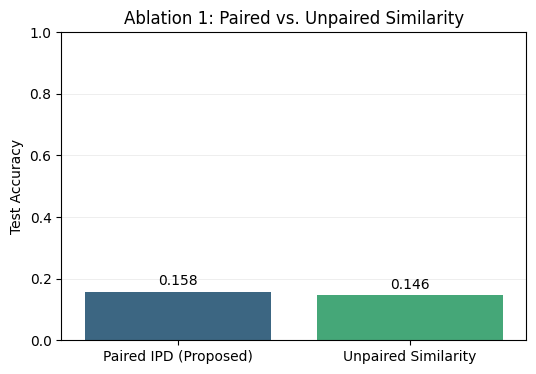

In [6]:
# Plotting Ablation 1
plt.figure(figsize=(6, 4))
sns.barplot(x=["Paired IPD (Proposed)", "Unpaired Similarity"], y=[acc_paired, acc_unpaired], palette="viridis")
plt.ylabel("Test Accuracy")
plt.title("Ablation 1: Paired vs. Unpaired Similarity")
plt.ylim(0, 1.0)
for i, v in enumerate([acc_paired, acc_unpaired]):
    plt.text(i, v + 0.02, f"{v:.3f}", ha='center')
plt.show()


## 4. Ablation 2: Adaptive LR vs. Fixed LR (H2)
We evaluate the impact of similarity-weighted learning-rate adaptation by training with a fixed learning-rate schedule across source domains.


In [7]:
acc_fixed_lr = train_and_evaluate(paired_order, paired_ipd, use_adaptive_lr=False)


AdaptiveTransferModel(
  (encoder): LSTM(9, 128, batch_first=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (classifier): Linear(in_features=128, out_features=19, bias=True)
)
Metrics: ['accuracy']
Device: mps

Training:
Batch size: 64
Optimizer: <class 'torch.optim.adam.Adam'>
Optimizer params: {'lr': 0.001}
Weight decay: 0.0
Max grad norm: None
Val dataloader: <torch.utils.data.dataloader.DataLoader object at 0x14b706950>
Monitor: accuracy
Monitor criterion: max
Epochs: 2
Patience: None



Epoch 0 / 2:   0%|          | 0/143 [00:00<?, ?it/s]

--- Train epoch-0, step-143 ---
loss: 2.7483


Evaluation: 100%|██████████| 143/143 [00:00<00:00, 146.19it/s]

--- Eval epoch-0, step-143 ---
accuracy: 0.1749
loss: 2.6734
New best accuracy score (0.1749) at epoch-0, step-143



...

Epoch 3 / 4:   0%|          | 0/143 [00:00<?, ?it/s]

--- Train epoch-3, step-572 ---
loss: 1.9786


Evaluation: 100%|██████████| 143/143 [00:01<00:00, 113.14it/s]

--- Eval epoch-3, step-572 ---
accuracy: 0.3529
loss: 1.8857
New best accuracy score (0.3529) at epoch-3, step-572
AdaptiveTransferModel(
  (encoder): LSTM(9, 128, batch_first=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (classifier): Linear(in_features=128, out_features=19, bias=True)
)
Metrics: ['accuracy']
Device: mps




Evaluation: 100%|██████████| 143/143 [00:01<00:00, 86.86it/s] 


/var/folders/_6/498k4xbs43l93lffcklb_r7m0000gn/T/ipykernel_74431/3808333002.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=["Adaptive LR (Proposed)", "Fixed LR"], y=[acc_paired, acc_fixed_lr], palette="magma")


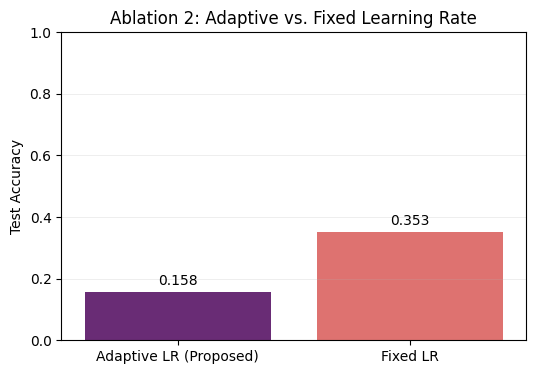

In [8]:
# Plotting Ablation 2
plt.figure(figsize=(6, 4))
sns.barplot(x=["Adaptive LR (Proposed)", "Fixed LR"], y=[acc_paired, acc_fixed_lr], palette="magma")
plt.ylabel("Test Accuracy")
plt.title("Ablation 2: Adaptive vs. Fixed Learning Rate")
plt.ylim(0, 1.0)
for i, v in enumerate([acc_paired, acc_fixed_lr]):
    plt.text(i, v + 0.02, f"{v:.3f}", ha='center')
plt.show()


## 5. Ablation 3: Robustness to Noise (H3)
We replicate the noise injection experiment using Gaussian perturbations to verify the robustness benefits of the transfer learning framework.


In [9]:
def evaluate_with_noise(model, test_ds, noise_stds):
    model.eval()
    test_loader = get_dataloader(test_ds, batch_size=BATCH_SIZE, shuffle=False)
    results = []
    
    for std in noise_stds:
        ys, ps = [], []
        for data in test_loader:
            data = {k: (v.to(DEVICE) if isinstance(v, torch.Tensor) else v) for k, v in data.items()}
            if std > 0:
                data["signal"] = data["signal"] + torch.randn_like(data["signal"]) * std
            with torch.no_grad():
                out = model(**data)
            ys.append(out["y_true"].cpu().numpy())
            ps.append(out["y_prob"].cpu().numpy())
        acc = multiclass_metrics_fn(np.concatenate(ys), np.concatenate(ps), metrics=["accuracy"])["accuracy"]
        results.append(acc)
    return results

# Train a No-Transfer baseline for comparison
no_transfer_model = AdaptiveTransferModel(dataset=bundles[TARGET_UNIT]["train"], feature_key="signal", backbone="lstm").to(DEVICE)
Trainer(model=no_transfer_model, device=DEVICE, metrics=["accuracy"], enable_logging=False).train(
    train_dataloader=get_dataloader(bundles[TARGET_UNIT]["train"], batch_size=BATCH_SIZE, shuffle=True),
    val_dataloader=get_dataloader(bundles[TARGET_UNIT]["val"], batch_size=BATCH_SIZE, shuffle=False),
    epochs=EPOCHS_PRETRAIN * len(SOURCE_UNITS) + EPOCHS_FINETUNE, optimizer_params={"lr": BASE_LR}, monitor="accuracy"
)

# Re-train adaptive model to evaluate
adaptive_model = AdaptiveTransferModel(dataset=bundles[TARGET_UNIT]["train"], feature_key="signal", backbone="lstm", use_similarity_weighting=True).to(DEVICE)
for src in paired_order:
    Trainer(model=adaptive_model, device=DEVICE, metrics=["accuracy"], enable_logging=False).train(
        train_dataloader=get_dataloader(bundles[src]["train"], batch_size=BATCH_SIZE, shuffle=True),
        val_dataloader=get_dataloader(bundles[src]["val"], batch_size=BATCH_SIZE, shuffle=False),
        epochs=EPOCHS_PRETRAIN, optimizer_params={"lr": adaptive_model.get_adaptive_lr(BASE_LR, 1.0 / (paired_ipd[src] + 1e-8))}, monitor="accuracy"
    )
Trainer(model=adaptive_model, device=DEVICE, metrics=["accuracy"], enable_logging=False).train(
    train_dataloader=get_dataloader(bundles[TARGET_UNIT]["train"], batch_size=BATCH_SIZE, shuffle=True),
    val_dataloader=get_dataloader(bundles[TARGET_UNIT]["val"], batch_size=BATCH_SIZE, shuffle=False),
    epochs=EPOCHS_FINETUNE, optimizer_params={"lr": BASE_LR}, monitor="accuracy"
)

noise_levels = [0.0, 0.05, 0.1, 0.2, 0.3]
acc_noise_no_transfer = evaluate_with_noise(no_transfer_model, bundles[TARGET_UNIT]["test"], noise_levels)
acc_noise_adaptive = evaluate_with_noise(adaptive_model, bundles[TARGET_UNIT]["test"], noise_levels)


AdaptiveTransferModel(
  (encoder): LSTM(9, 128, batch_first=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (classifier): Linear(in_features=128, out_features=19, bias=True)
)
Metrics: ['accuracy']
Device: mps

Training:
Batch size: 64
Optimizer: <class 'torch.optim.adam.Adam'>
Optimizer params: {'lr': 0.001}
Weight decay: 0.0
Max grad norm: None
Val dataloader: <torch.utils.data.dataloader.DataLoader object at 0x14b706150>
Monitor: accuracy
Monitor criterion: max
Epochs: 12
Patience: None



Epoch 0 / 12:   0%|          | 0/143 [00:00<?, ?it/s]

--- Train epoch-0, step-143 ---
loss: 2.7731


Evaluation: 100%|██████████| 143/143 [00:01<00:00, 111.53it/s]

--- Eval epoch-0, step-143 ---
accuracy: 0.1209
loss: 2.6780
New best accuracy score (0.1209) at epoch-0, step-143



...

--- Eval epoch-2, step-429 ---
accuracy: 0.4826
loss: 1.3729
New best accuracy score (0.4826) at epoch-2, step-429



Epoch 3 / 4:   0%|          | 0/143 [00:00<?, ?it/s]

--- Train epoch-3, step-572 ---
loss: 1.3228


Evaluation: 100%|██████████| 143/143 [00:01<00:00, 110.52it/s]

--- Eval epoch-3, step-572 ---
accuracy: 0.5393
loss: 1.2536
New best accuracy score (0.5393) at epoch-3, step-572


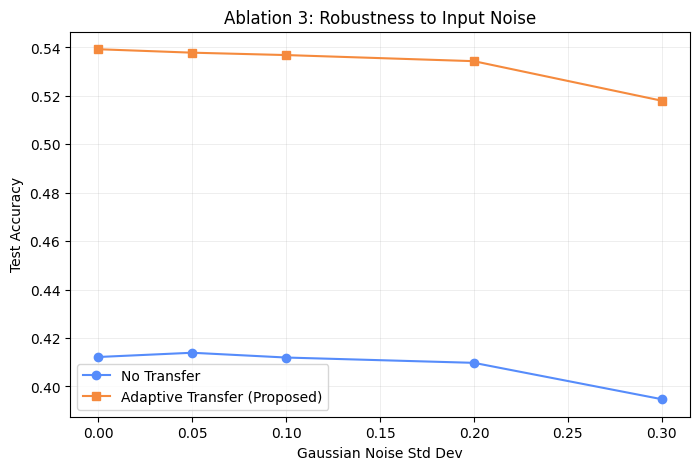

In [10]:
# Plotting Ablation 3
plt.figure(figsize=(8, 5))
plt.plot(noise_levels, acc_noise_no_transfer, marker='o', label="No Transfer")
plt.plot(noise_levels, acc_noise_adaptive, marker='s', label="Adaptive Transfer (Proposed)")
plt.xlabel("Gaussian Noise Std Dev")
plt.ylabel("Test Accuracy")
plt.title("Ablation 3: Robustness to Input Noise")
plt.legend()
plt.show()


## 6. Extension: Distance Metrics Comparison
We evaluate various distance methods within IPD: Euclidean, Minkowski (p=3), and DTW.


In [11]:
distance_metrics = {
    "DTW": dtw_distance_fn,
    "Euclidean": "euclidean",
    "Minkowski (p=3)": lambda x, y: F.pairwise_distance(x, y, p=3)
}

metric_results = {}
ipd_heatmap_data = np.zeros((len(distance_metrics), len(SOURCE_UNITS)))

for i, (name, dist_fn) in enumerate(distance_metrics.items()):
    ipd_vals = {src: compute_mean_ipd(bundles[src]["val"], bundles[TARGET_UNIT]["val"], distance_fn=dist_fn) for src in SOURCE_UNITS}
    order = sorted(SOURCE_UNITS, key=ipd_vals.get)
    acc = train_and_evaluate(order, ipd_vals, use_adaptive_lr=True)
    metric_results[name] = acc
    
    for j, src in enumerate(SOURCE_UNITS):
        ipd_heatmap_data[i, j] = ipd_vals[src]


AdaptiveTransferModel(
  (encoder): LSTM(9, 128, batch_first=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (classifier): Linear(in_features=128, out_features=19, bias=True)
)
Metrics: ['accuracy']
Device: mps

Training:
Batch size: 64
Optimizer: <class 'torch.optim.adam.Adam'>
Optimizer params: {'lr': 0.0027188117381005015}
Weight decay: 0.0
Max grad norm: None
Val dataloader: <torch.utils.data.dataloader.DataLoader object at 0x14b17af50>
Monitor: accuracy
Monitor criterion: max
Epochs: 2
Patience: None



Epoch 0 / 2:   0%|          | 0/143 [00:00<?, ?it/s]

--- Train epoch-0, step-143 ---
loss: 2.7586


Evaluation: 100%|██████████| 143/143 [00:01<00:00, 104.25it/s]

--- Eval epoch-0, step-143 ---
accuracy: 0.1523
loss: 2.6260
New best accuracy score (0.1523) at epoch-0, step-143



...

Epoch 3 / 4:   0%|          | 0/143 [00:00<?, ?it/s]

--- Train epoch-3, step-572 ---
loss: 1.7432


Evaluation: 100%|██████████| 143/143 [00:01<00:00, 98.05it/s] 

--- Eval epoch-3, step-572 ---
accuracy: 0.4391
loss: 1.5595
New best accuracy score (0.4391) at epoch-3, step-572
AdaptiveTransferModel(
  (encoder): LSTM(9, 128, batch_first=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (classifier): Linear(in_features=128, out_features=19, bias=True)
)
Metrics: ['accuracy']
Device: mps




Evaluation: 100%|██████████| 143/143 [00:01<00:00, 105.88it/s]


/var/folders/_6/498k4xbs43l93lffcklb_r7m0000gn/T/ipykernel_74431/688061611.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(metric_results.keys()), y=list(metric_results.values()), palette="coolwarm")


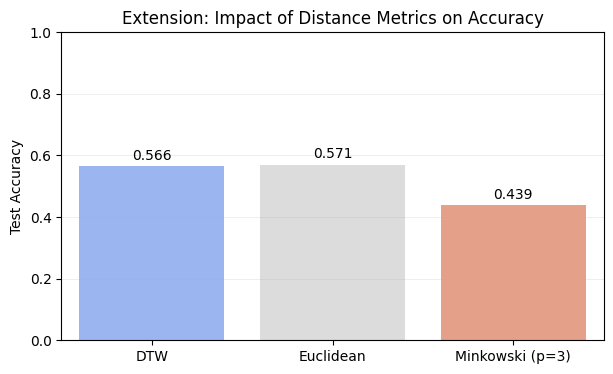

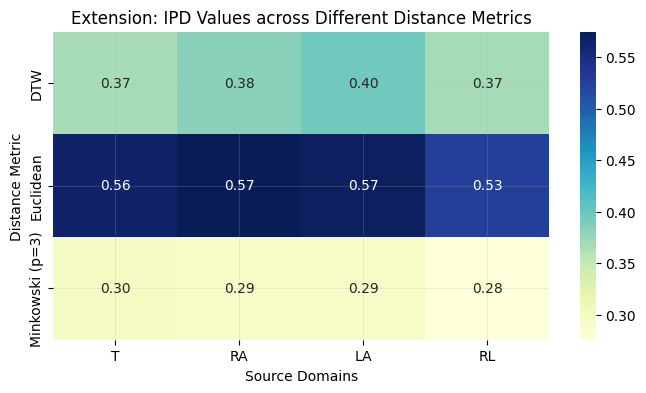

In [12]:
# Plotting Extension Results
# 1. Bar Chart for Accuracy Comparison
plt.figure(figsize=(7, 4))
sns.barplot(x=list(metric_results.keys()), y=list(metric_results.values()), palette="coolwarm")
plt.ylabel("Test Accuracy")
plt.title("Extension: Impact of Distance Metrics on Accuracy")
plt.ylim(0, 1.0)
for i, v in enumerate(metric_results.values()):
    plt.text(i, v + 0.02, f"{v:.3f}", ha='center')
plt.show()

# 2. Heatmap for IPD Values across Metrics
plt.figure(figsize=(8, 4))
sns.heatmap(ipd_heatmap_data, annot=True, fmt=".2f", xticklabels=SOURCE_UNITS, yticklabels=list(distance_metrics.keys()), cmap="YlGnBu")
plt.xlabel("Source Domains")
plt.ylabel("Distance Metric")
plt.title("Extension: IPD Values across Different Distance Metrics")
plt.show()
